# Treinamento - Regressão Logística (Baseline)

## Objetivo

Treinar um modelo de Regressão Logística como baseline comparativo para predição de abandono do tratamento de tuberculose (LTFU).

## Estratégia de Avaliação

- **Rodada 1:** treino → teste1 (validação interna)
- **Rodada 2:** treino + teste1 → teste2 (validação externa)

## Métricas Utilizadas

- Recall
- Precisão
- F1-score
- Acurácia
- ROC-AUC

**Recall** foi considerado a principal métrica do projeto, pois o objetivo é identificar o maior número possível de pacientes com risco de abandono.

## Tratamento do Desbalanceamento

- Class Weights
- Sample Weights para pacientes reingressos após abandono

## Melhorias incorporadas

- **RandomizedSearchCV:** busca dos melhores hiperparâmetros (`C` e `l1_ratio`) antes de treinar o modelo final
- **Análise de Threshold:** curva Precisão × Recall para encontrar o threshold ideal em contexto clínico

## Explicabilidade

Foram analisados os coeficientes do modelo e a técnica de **Permutation Importance**.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.utils import class_weight
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    ConfusionMatrixDisplay, RocCurveDisplay,
    f1_score, recall_score, precision_score
)
from sklearn.inspection import permutation_importance

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE = '/content/drive/MyDrive/'
os.makedirs(BASE + 'graficos', exist_ok=True)

## CARREGAMENTO DOS DADOS

In [ ]:
X_train = pd.read_csv(BASE + 'X_train_proc.csv')
X_test1 = pd.read_csv(BASE + 'X_test1_proc.csv')
X_test2 = pd.read_csv(BASE + 'X_test2_proc.csv')

y_train = pd.read_csv(BASE + 'y_train.csv').squeeze()
y_test1 = pd.read_csv(BASE + 'y_test1.csv').squeeze()
y_test2 = pd.read_csv(BASE + 'y_test2.csv').squeeze()

# Rodada 2: treino expandido = treino + teste1
X_train2 = pd.concat([X_train, X_test1], ignore_index=True)
y_train2 = pd.concat([y_train, y_test1], ignore_index=True)

# Converter para numpy
X_train_np  = X_train.values.astype('float32')
X_test1_np  = X_test1.values.astype('float32')
X_test2_np  = X_test2.values.astype('float32')
X_train2_np = X_train2.values.astype('float32')

y_train_np  = y_train.values.astype('int32')
y_test1_np  = y_test1.values.astype('int32')
y_test2_np  = y_test2.values.astype('int32')
y_train2_np = y_train2.values.astype('int32')

print(f'X_train : {X_train_np.shape}')
print(f'X_test1 : {X_test1_np.shape}')
print(f'X_train2: {X_train2_np.shape}')
print(f'X_test2 : {X_test2_np.shape}')
print(
    f'\nTaxa abandono - treino: {y_train_np.mean()*100:.1f}% | '
    f'teste1: {y_test1_np.mean()*100:.1f}% | '
    f'teste2: {y_test2_np.mean()*100:.1f}%'
)

X_train : (562632, 25)
X_test1 : (631, 25)
X_train2: (563263, 25)
X_test2 : (631, 25)

Taxa abandono - treino: 19.4% | teste1: 43.9% | teste2: 69.4%


## CLASS WEIGHTS E SAMPLE WEIGHTS

In [ ]:
# Class weights — Rodada 1
pesos = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)
pesos_dict = dict(enumerate(pesos))
print(f'Class weights Rodada 1: {pesos_dict}')

# Class weights — Rodada 2 (recalculado com treino expandido)
pesos2 = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train2_np),
    y=y_train2_np
)
pesos2_dict = dict(enumerate(pesos2))
print(f'Class weights Rodada 2: {pesos2_dict}')

col_trat  = X_train.columns.get_loc('TRATAMENTO')
col_trat2 = X_train2.columns.get_loc('TRATAMENTO')

# Sample weights: reingressos (TRATAMENTO OrdinalEncoder=2.0) com peso 3x extra
def calcular_sample_weight(X_np, y_np, pesos_dict, col_trat, peso_reing=3.0):
    sw = np.where(y_np == 1, pesos_dict[1], pesos_dict[0]).astype('float32')
    mask_reing = (X_np[:, col_trat] == 2.0)
    sw[mask_reing] *= peso_reing
    n_reing = mask_reing.sum()
    print(f'  Reingressos: {n_reing} ({n_reing/len(X_np)*100:.1f}%) com peso {peso_reing}x extra')
    return sw

print('\nSample weights - Rodada 1:')
sw_train = calcular_sample_weight(X_train_np, y_train_np, pesos_dict, col_trat)

print('Sample weights - Rodada 2:')
sw_train2 = calcular_sample_weight(X_train2_np, y_train2_np, pesos2_dict, col_trat2)

Class weights Rodada 1: {0: np.float64(0.6204888635972632), 1: np.float64(2.574880553572409)}
Class weights Rodada 2: {0: np.float64(0.6207001049077429), 1: np.float64(2.5712492353762864)}

Sample weights - Rodada 1:
  Reingressos: 58090 (10.3%) com peso 3.0x extra
Sample weights - Rodada 2:
  Reingressos: 58319 (10.4%) com peso 3.0x extra


## FUNÇÕES DE AVALIAÇÃO

In [ ]:
def avaliar(nome, y_true, y_pred, y_prob):
    print(f'\n{nome}')
    print(classification_report(y_true, y_pred,
                                 target_names=['Não abandona (0)', 'Abandona (1)']))
    auc = roc_auc_score(y_true, y_prob)
    print(f'ROC-AUC: {auc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=axes[0],
        display_labels=['Não abandona', 'Abandona'],
        colorbar=False
    )
    axes[0].set_title(f'Matriz de Confusão - {nome}')
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[1])
    axes[1].set_title(f'Curva ROC - {nome} (AUC={auc:.3f})')
    axes[1].plot([0, 1], [0, 1], '--', color='gray')
    plt.tight_layout()
    plt.savefig(f'{BASE}graficos/{nome}.png', dpi=300, bbox_inches='tight')
    plt.show()
    return auc

print('Funções definidas!')

Funções definidas!


## MELHORIA 1: BUSCA DE HIPERPARÂMETROS (RandomizedSearchCV)

Em vez de fixar `C=1.0` sem validação, usamos `RandomizedSearchCV` para encontrar a melhor
combinação de hiperparâmetros da Regressão Logística.

**Parâmetros testados:**
- **`C`**: força de regularização (valores maiores = menos regularização)
- **`penalty`**: tipo de regularização — `l2` (Ridge) ou `elasticnet` (L1+L2 combinados)
- **`l1_ratio`**: proporção L1 dentro do ElasticNet (só usado quando `penalty='elasticnet'`)

**Estratégia:**
- 20 combinações aleatórias (por conta do tempo demandado foi diminiudo o valor)
- 3 folds com `StratifiedKFold` (mantém proporção de classes em cada fold)
- Métrica de seleção: **ROC-AUC** (independente do threshold)
- `sample_weight` aplicado dentro do CV via `fit_params`

> **Por que não SMOTE?** Não utilizamos o SMOTE para banalcear pois tratamos o desbalanceamento com `class_weight` + `sample_weight`.

In [ ]:
# Grade de hiperparâmetros — faixa estreitada em torno do C=1.0 que já funcionou
grid = {
    'C':        np.logspace(-1, 1, 50),    # de 0.1 a 10
    'penalty':  ['l2', 'elasticnet'],
    'l1_ratio': np.linspace(0.1, 0.9, 20), # só usado no elasticnet
}

# Amostra estratificada de 20% do treino para a busca
# stratify garante que a proporção de abandonos (~19%, como o conjunto original) seja mantida
from sklearn.model_selection import train_test_split

X_busca, _, y_busca, _, sw_busca, _ = train_test_split(
    X_train_np, y_train_np, sw_train,
    train_size=0.20,
    stratify=y_train_np,
    random_state=42
)
print(f'Amostras para busca: {X_busca.shape[0]} ({X_busca.shape[0]/len(X_train_np)*100:.0f}% do treino)')
print(f'Taxa abandono na amostra: {y_busca.mean()*100:.1f}%')

# Modelo base para a busca
modelo_busca = LogisticRegression(
    solver='saga',
    max_iter=1000,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=modelo_busca,
    param_distributions=grid,
    n_iter=50,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    refit=False, #desativa o retreinamento automático com os melhores parâmetros, pois é feito manualmente para ter controle sobre o sample_weight dos reingressos
    random_state=42,
    verbose=1
)

print('\nIniciando RandomizedSearchCV (50 combinações × 3 folds = 150 treinos)...')
random_search.fit(X_busca, y_busca, sample_weight=sw_busca)  # usa a amostra, não o treino completo
print('\nBusca concluída!')

Amostras para busca: 112526 (20% do treino)
Taxa abandono na amostra: 19.4%

Iniciando RandomizedSearchCV (50 combinações × 3 folds = 150 treinos)...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Busca concluída!


In [ ]:
# Exibir os melhores resultados da busca
metricas_interesse = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_fit_time',
    'params'
]

df_resultados_busca = (
    pd.DataFrame(random_search.cv_results_)[metricas_interesse]
    .sort_values('rank_test_score')
    .head(10)
    .reset_index(drop=True)
)

pd.options.display.float_format = '{:.4f}'.format
print('Top 10 combinações de hiperparâmetros (por ROC-AUC no CV):')
print(df_resultados_busca.to_string(index=False))

Top 10 combinações de hiperparâmetros (por ROC-AUC no CV):
 rank_test_score  mean_test_score  std_test_score  mean_fit_time                                                                              params
               1           0.7088          0.0004        57.1933         {'penalty': 'l2', 'l1_ratio': 0.8157894736842105, 'C': 0.44984326689694454}
               1           0.7088          0.0004        56.2319          {'penalty': 'l2', 'l1_ratio': 0.6473684210526316, 'C': 0.5428675439323859}
               3           0.7088          0.0004        49.6438           {'penalty': 'l2', 'l1_ratio': 0.6052631578947368, 'C': 0.372759372031494}
               3           0.7088          0.0004        56.9097          {'penalty': 'l2', 'l1_ratio': 0.6894736842105262, 'C': 0.4094915062380424}
               3           0.7088          0.0004        58.0178           {'penalty': 'l2', 'l1_ratio': 0.3526315789473684, 'C': 0.372759372031494}
               6           0.7088          0.00

In [ ]:
# Extrair os melhores parâmetros
idx_melhor = np.argmin(random_search.cv_results_['rank_test_score'])
melhores_params = random_search.cv_results_['params'][idx_melhor]
melhor_auc_cv   = random_search.cv_results_['mean_test_score'][idx_melhor]

print(f'Melhores hiperparâmetros encontrados:')
for k, v in melhores_params.items():
    print(f'  {k}: {v}')
print(f'\nROC-AUC médio no CV: {melhor_auc_cv:.4f}')

# Se o melhor for l2, l1_ratio não se aplica — removemos para evitar warning
if melhores_params.get('penalty') == 'l2':
    melhores_params_final = {k: v for k, v in melhores_params.items() if k != 'l1_ratio'}
else:
    melhores_params_final = melhores_params

print(f'\nParâmetros para o modelo final: {melhores_params_final}')

Melhores hiperparâmetros encontrados:
  penalty: l2
  l1_ratio: 0.6473684210526316
  C: 0.5428675439323859

ROC-AUC médio no CV: 0.7088

Parâmetros para o modelo final: {'penalty': 'l2', 'C': np.float64(0.5428675439323859)}


## RODADA 1: treino → teste1

In [ ]:
# Treinar com os melhores hiperparâmetros encontrados na busca
modelo_RL = LogisticRegression(
    **melhores_params_final,
    solver='saga',
    max_iter=1000,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

print('Treinando Regressão Logística - Rodada 1...')
modelo_RL.fit(X_train_np, y_train_np, sample_weight=sw_train)
print('Treinamento concluído!')

Treinando Regressão Logística - Rodada 1...
Treinamento concluído!



RegressaoLogistica_Teste1
                  precision    recall  f1-score   support

Não abandona (0)       0.84      0.35      0.50       354
    Abandona (1)       0.53      0.92      0.67       277

        accuracy                           0.60       631
       macro avg       0.69      0.64      0.58       631
    weighted avg       0.70      0.60      0.57       631

ROC-AUC: 0.7594


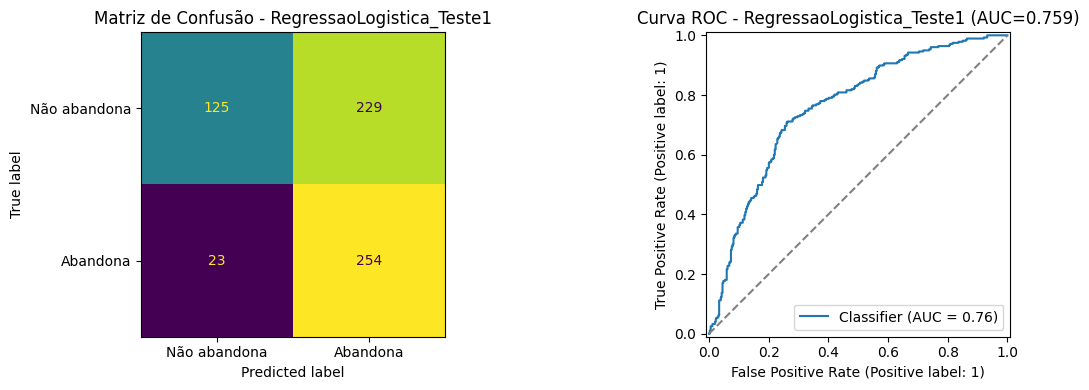

In [ ]:
prob_test1 = modelo_RL.predict_proba(X_test1_np)[:, 1] #seleciona só a probabilidade de abandono (classe 1), que é o que interessa
pred_test1 = (prob_test1 >= 0.5).astype(int)
auc1 = avaliar('RegressaoLogistica_Teste1', y_test1_np, pred_test1, prob_test1)

## RODADA 2: treino + teste1 → teste2

In [ ]:
modelo_RL2 = LogisticRegression(
    **melhores_params_final,
    solver='saga',
    max_iter=1000,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

print('Treinando Regressão Logística - Rodada 2...')
modelo_RL2.fit(X_train2_np, y_train2_np, sample_weight=sw_train2)
print('Treinamento concluído!')

Treinando Regressão Logística - Rodada 2...
Treinamento concluído!



RegressaoLogistica_Teste2
                  precision    recall  f1-score   support

Não abandona (0)       0.66      0.22      0.33       193
    Abandona (1)       0.73      0.95      0.83       438

        accuracy                           0.73       631
       macro avg       0.70      0.59      0.58       631
    weighted avg       0.71      0.73      0.68       631

ROC-AUC: 0.6811


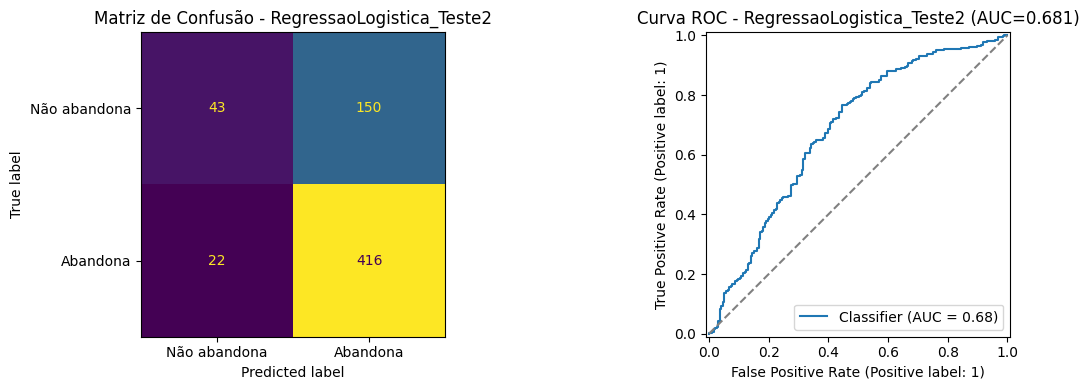

In [ ]:
prob_test2 = modelo_RL2.predict_proba(X_test2_np)[:, 1]
pred_test2 = (prob_test2 >= 0.5).astype(int)
auc2 = avaliar('RegressaoLogistica_Teste2', y_test2_np, pred_test2, prob_test2)

## MELHORIA 2: ANÁLISE DE THRESHOLD

Por padrão, usamos `threshold=0.5` para transformar probabilidades em classificações binárias.
Mas esse valor pode não ser o ideal para o nosso contexto clínico.

**Trade-off clínico:**
- **Threshold baixo (ex: 0.3)** → mais pacientes classificados como risco → **Recall maior**, Precisão menor
  - *Melhor para não deixar ninguém em risco passar despercebido*
- **Threshold alto (ex: 0.7)** → menos alarmes falsos → **Precisão maior**, Recall menor
  - *Melhor quando os recursos de intervenção são muito limitados*

Como o objetivo do projeto é **identificar o máximo de pacientes em risco**, um threshold
mais baixo que 0.5 pode ser mais adequado clinicamente.

Analisamos o threshold no **Teste1** (maior amostra) para ter uma estimativa mais estável.

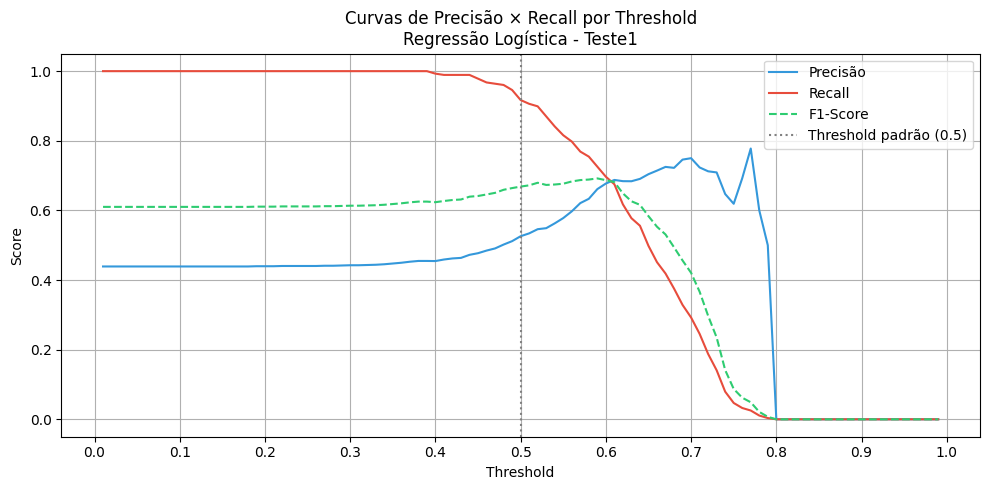

In [ ]:
# Análise de threshold
# Testamos todos os thresholds de 0.01 a 0.99 no Teste1
threshold_scores = {'threshold': [], 'recall': [], 'precision': [], 'f1': [], 'acuracia': []}

for t in np.arange(0.01, 1.0, 0.01):
    preds_t = (prob_test1 >= t).astype(int)
    threshold_scores['threshold'].append(round(t, 2))
    threshold_scores['recall'].append(recall_score(y_test1_np, preds_t, zero_division=0))
    threshold_scores['precision'].append(precision_score(y_test1_np, preds_t, zero_division=0))
    threshold_scores['f1'].append(f1_score(y_test1_np, preds_t, zero_division=0))
    threshold_scores['acuracia'].append(accuracy_score(y_test1_np, preds_t))

df_thresh = pd.DataFrame(threshold_scores)

# Visualização das curvas
plt.figure(figsize=(10, 5))
plt.plot(df_thresh['threshold'], df_thresh['precision'], label='Precisão', color='#3498db')
plt.plot(df_thresh['threshold'], df_thresh['recall'],    label='Recall',   color='#e74c3c')
plt.plot(df_thresh['threshold'], df_thresh['f1'],        label='F1-Score', color='#2ecc71', linestyle='--')
plt.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Threshold padrão (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Curvas de Precisão × Recall por Threshold\nRegressão Logística - Teste1')
plt.xticks(np.arange(0, 1.1, 0.1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{BASE}graficos/threshold_analysis_RL.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Identificar threshold ideal
idx_melhor_f1     = df_thresh['f1'].idxmax()
idx_melhor_recall = (df_thresh['recall'] >= 0.85).idxmax()

t_f1     = df_thresh.loc[idx_melhor_f1,     'threshold']
t_recall = df_thresh.loc[idx_melhor_recall, 'threshold']

print(f'Threshold com melhor F1-Score : {t_f1:.2f}')
print(f'  Precisão: {df_thresh.loc[idx_melhor_f1, "precision"]:.4f}')
print(f'  Recall  : {df_thresh.loc[idx_melhor_f1, "recall"]:.4f}')
print(f'  F1      : {df_thresh.loc[idx_melhor_f1, "f1"]:.4f}')

print(f'\nPrimeiro threshold com Recall >= 85%: {t_recall:.2f}')
print(f'  Precisão: {df_thresh.loc[idx_melhor_recall, "precision"]:.4f}')
print(f'  Recall  : {df_thresh.loc[idx_melhor_recall, "recall"]:.4f}')
print(f'  F1      : {df_thresh.loc[idx_melhor_recall, "f1"]:.4f}')

# Comparativo dos dois thresholds candidatos
print('\n' + '='*60)
print('Comparativo dos thresholds candidatos — Teste1')
print('='*60)
print(f'{"Threshold":<12} {"Recall":<10} {"Precisão":<12} {"F1":<10} {"Acurácia"}')
print('-'*60)
for t in [0.40, 0.50]:
    pred = (prob_test1 >= t).astype(int)
    print(
        f't={t:.2f}       '
        f'{recall_score(y_test1_np, pred):.4f}    '
        f'{precision_score(y_test1_np, pred):.4f}        '
        f'{f1_score(y_test1_np, pred):.4f}    '
        f'{accuracy_score(y_test1_np, pred):.4f}'
    )
print('='*60)
print('\nInterpretação clínica:')
print('  t=0.40 → triagem populacional (Recall alto, aceita mais falsos alarmes)')
print('  t=0.50 → ponto neutro de referência')

# Lógica de três níveis de risco para uso na API
print('\nLógica de risco por faixa de probabilidade (para a API):')
print('  prob < 0.40          →  Risco Baixo')
print('  0.40 <= prob < 0.65  →  Risco Moderado')
print('  prob >= 0.65         →  Risco Alto')

# Threshold final — usando 0.40 para priorizar detecção de casos
THRESHOLD_FINAL = 0.40
print(f'\n>>> Threshold final selecionado: {THRESHOLD_FINAL:.2f}')

Threshold com melhor F1-Score : 0.59
  Precisão: 0.6612
  Recall  : 0.7256
  F1      : 0.6919

Primeiro threshold com Recall >= 85%: 0.01
  Precisão: 0.4390
  Recall  : 1.0000
  F1      : 0.6101

Comparativo dos thresholds candidatos — Teste1
Threshold    Recall     Precisão     F1         Acurácia
------------------------------------------------------------
t=0.40       0.9928    0.4545        0.6236    0.4739
t=0.50       0.9170    0.5259        0.6684    0.6006

Interpretação clínica:
  t=0.40 → triagem populacional (Recall alto, aceita mais falsos alarmes)
  t=0.50 → ponto neutro de referência

Lógica de risco por faixa de probabilidade (para a API):
  prob < 0.40          →  Risco Baixo
  0.40 <= prob < 0.65  →  Risco Moderado
  prob >= 0.65         →  Risco Alto

>>> Threshold final selecionado: 0.40


Reavaliando modelos com t=0.40 e t=0.50


RegressaoLogistica_Teste1_t0.40
                  precision    recall  f1-score   support

Não abandona (0)       0.92      0.07      0.13       354
    Abandona (1)       0.45      0.99      0.62       277

        accuracy                           0.47       631
       macro avg       0.69      0.53      0.37       631
    weighted avg       0.72      0.47      0.34       631

ROC-AUC: 0.7594


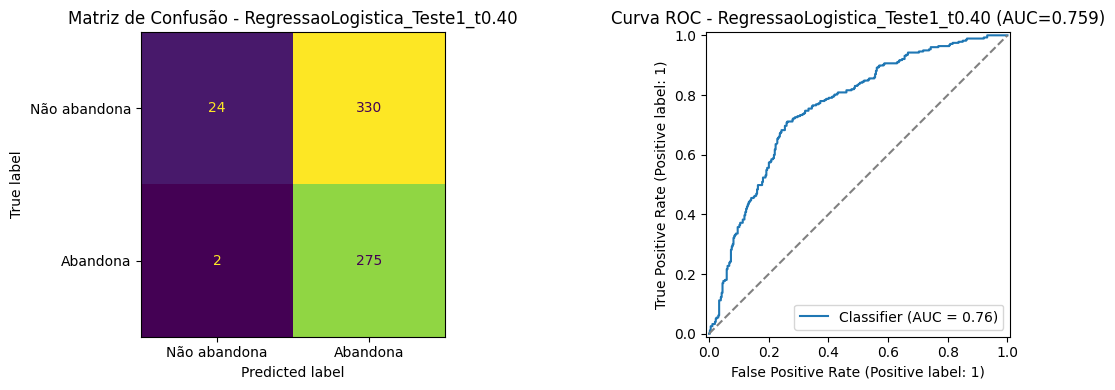


RegressaoLogistica_Teste2_t0.40
                  precision    recall  f1-score   support

Não abandona (0)       0.56      0.05      0.09       193
    Abandona (1)       0.70      0.98      0.82       438

        accuracy                           0.70       631
       macro avg       0.63      0.52      0.46       631
    weighted avg       0.66      0.70      0.60       631

ROC-AUC: 0.6811


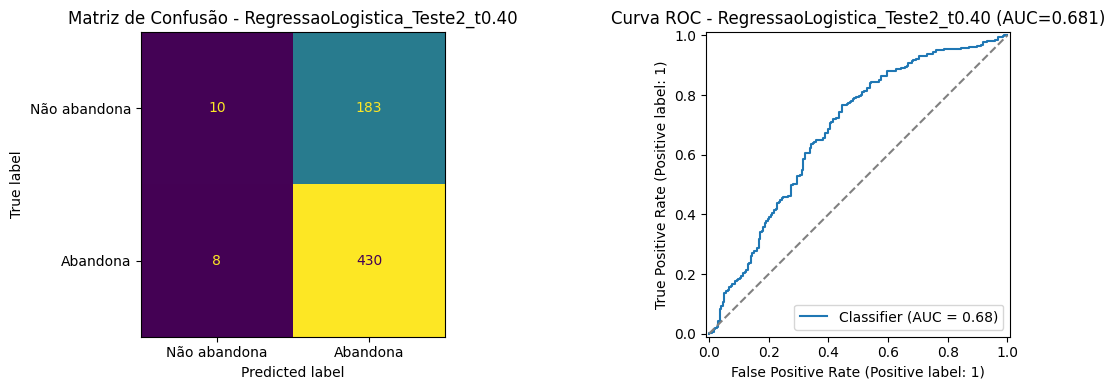


RegressaoLogistica_Teste1_t0.50
                  precision    recall  f1-score   support

Não abandona (0)       0.84      0.35      0.50       354
    Abandona (1)       0.53      0.92      0.67       277

        accuracy                           0.60       631
       macro avg       0.69      0.64      0.58       631
    weighted avg       0.70      0.60      0.57       631

ROC-AUC: 0.7594


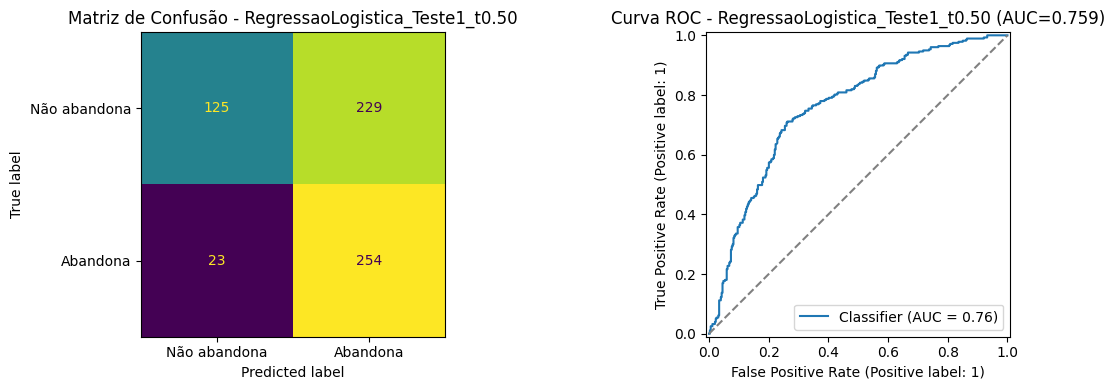


RegressaoLogistica_Teste2_t0.50
                  precision    recall  f1-score   support

Não abandona (0)       0.66      0.22      0.33       193
    Abandona (1)       0.73      0.95      0.83       438

        accuracy                           0.73       631
       macro avg       0.70      0.59      0.58       631
    weighted avg       0.71      0.73      0.68       631

ROC-AUC: 0.6811


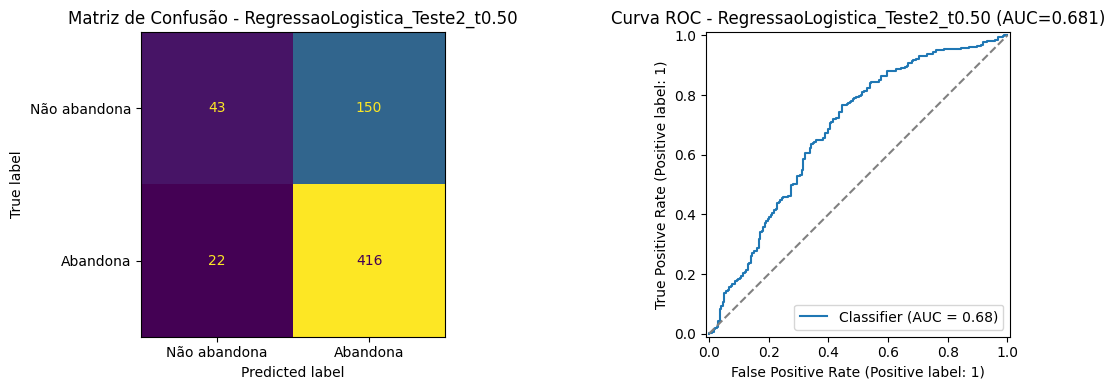

In [ ]:
# Reavaliar ambas as rodadas com os dois thresholds
print('Reavaliando modelos com t=0.40 e t=0.50\n')

# Threshold 0.40
pred_test1_40 = (prob_test1 >= 0.40).astype(int)
pred_test2_40 = (prob_test2 >= 0.40).astype(int)
auc1_40 = avaliar('RegressaoLogistica_Teste1_t0.40', y_test1_np, pred_test1_40, prob_test1)
auc2_40 = avaliar('RegressaoLogistica_Teste2_t0.40', y_test2_np, pred_test2_40, prob_test2)

# Threshold 0.50
pred_test1_50 = (prob_test1 >= 0.50).astype(int)
pred_test2_50 = (prob_test2 >= 0.50).astype(int)
auc1_50 = avaliar('RegressaoLogistica_Teste1_t0.50', y_test1_np, pred_test1_50, prob_test1)
auc2_50 = avaliar('RegressaoLogistica_Teste2_t0.50', y_test2_np, pred_test2_50, prob_test2)

## ANÁLISE DOS COEFICIENTES

Diferentemente da Rede Neural, a Regressão Logística é diretamente interpretável.

- **Coeficiente positivo** → variável aumenta a probabilidade de abandono
- **Coeficiente negativo** → variável reduz a probabilidade de abandono
- **Odds Ratio > 1** → fator de risco | **Odds Ratio < 1** → fator de proteção

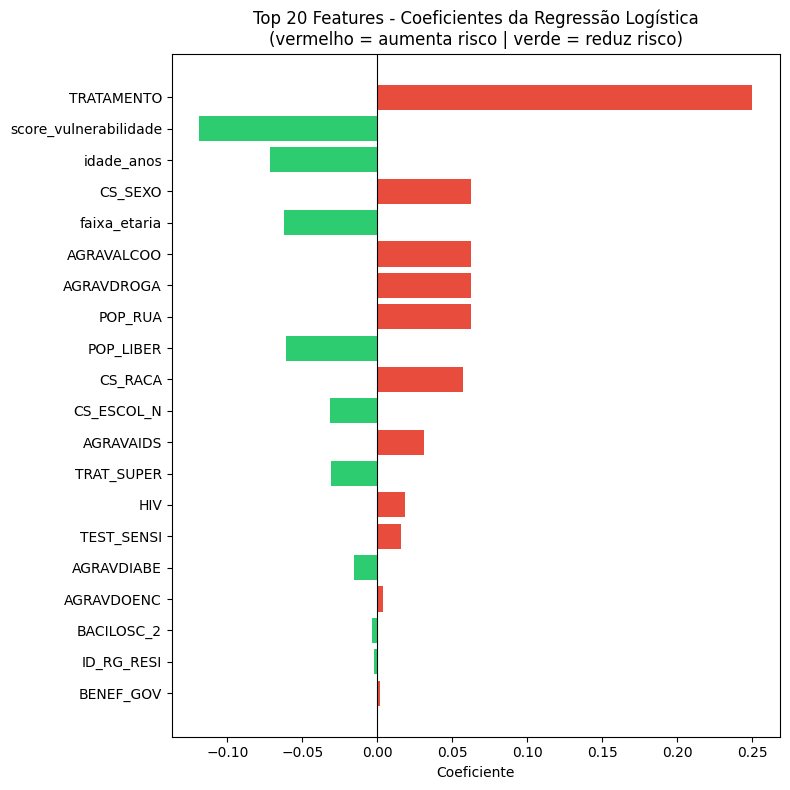


Top 10 features por impacto:
              feature  coeficiente  odds_ratio
           TRATAMENTO       0.2500      1.2840
score_vulnerabilidade      -0.1187      0.8881
           idade_anos      -0.0719      0.9306
              CS_SEXO       0.0625      1.0645
         faixa_etaria      -0.0625      0.9394
           AGRAVALCOO       0.0625      1.0645
           AGRAVDROGA       0.0625      1.0645
              POP_RUA       0.0625      1.0645
            POP_LIBER      -0.0607      0.9412
              CS_RACA       0.0572      1.0589


In [ ]:
col_names = X_train2.columns.tolist()

df_coef = pd.DataFrame({
    'feature':     col_names,
    'coeficiente': modelo_RL2.coef_[0],
    'odds_ratio':  np.exp(modelo_RL2.coef_[0])
})

df_coef = df_coef.reindex(
    df_coef['coeficiente'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

top20 = df_coef.head(20)

plt.figure(figsize=(8, 8))
cores = ['#e74c3c' if v > 0 else '#2ecc71' for v in top20['coeficiente'][::-1]]
plt.barh(top20['feature'][::-1], top20['coeficiente'][::-1], color=cores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features - Coeficientes da Regressão Logística\n(vermelho = aumenta risco | verde = reduz risco)')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.savefig(f'{BASE}graficos/coeficientes_RL.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nTop 10 features por impacto:')
print(df_coef.head(10).to_string(index=False))

Calculando Permutation Importance com 631 amostras...
Concluído!


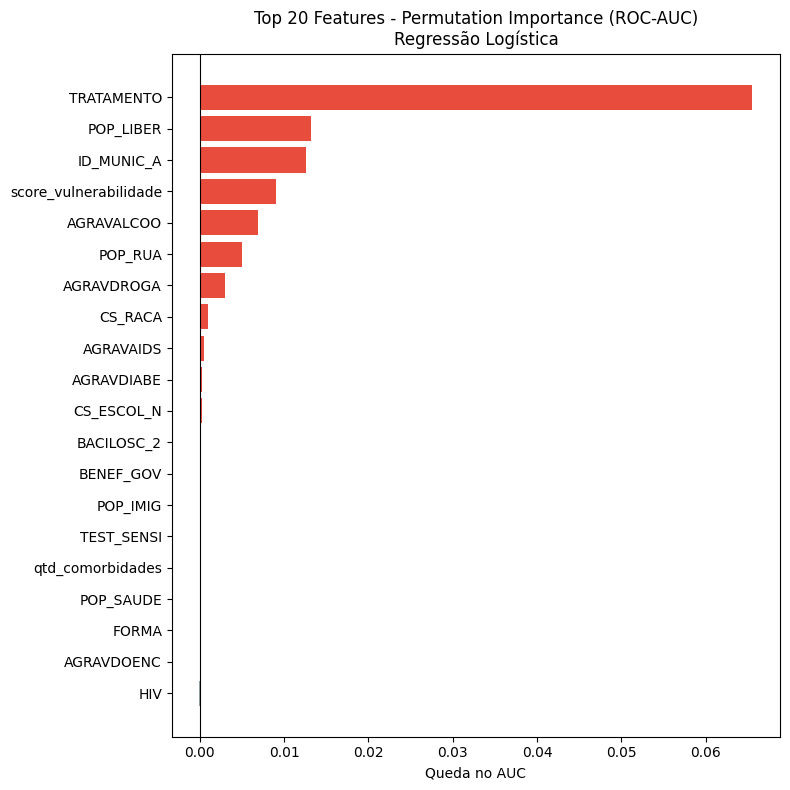


Top 10 features:
              feature  importancia
           TRATAMENTO       0.0655
            POP_LIBER       0.0132
           ID_MUNIC_A       0.0126
score_vulnerabilidade       0.0090
           AGRAVALCOO       0.0069
              POP_RUA       0.0050
           AGRAVDROGA       0.0030
              CS_RACA       0.0009
            AGRAVAIDS       0.0005
           AGRAVDIABE       0.0003


In [ ]:
sample_size = min(2000, len(X_test2_np))
idx = np.random.choice(len(X_test2_np), sample_size, replace=False)
X_sample = X_test2_np[idx]
y_sample = y_test2_np[idx]

print(f'Calculando Permutation Importance com {sample_size} amostras...')
result = permutation_importance(
    modelo_RL2,
    X_sample, y_sample,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)
print('Concluído!')

df_imp = pd.DataFrame({
    'feature':     X_test2.columns.tolist(),
    'importancia': result.importances_mean
})
df_imp = df_imp.sort_values('importancia', ascending=False).reset_index(drop=True)

top20_imp = df_imp.head(20)
plt.figure(figsize=(8, 8))
plt.barh(
    top20_imp['feature'][::-1],
    top20_imp['importancia'][::-1],
    color=['#e74c3c' if v > 0 else '#95a5a6' for v in top20_imp['importancia'][::-1]]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features - Permutation Importance (ROC-AUC)\nRegressão Logística')
plt.xlabel('Queda no AUC')
plt.tight_layout()
plt.savefig(f'{BASE}graficos/permutation_RL.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
print(df_imp.head(10).to_string(index=False))

## RESUMO DE MÉTRICAS

In [ ]:
def resumo_metricas(nome, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Modelo':    nome,
        'Threshold': threshold,
        'Acurácia':  accuracy_score(y_true, y_pred),
        'Precisão':  precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'ROC-AUC':   roc_auc_score(y_true, y_prob)
    }

pd.options.display.float_format = '{:.4f}'.format

resultados = pd.DataFrame([
    # Threshold 0.40 — foco em triagem, Recall alto
    resumo_metricas('Rodada 1 - Teste1 (t=0.40)', y_test1_np, prob_test1, 0.40),
    resumo_metricas('Rodada 2 - Teste2 (t=0.40)', y_test2_np, prob_test2, 0.40),
    # Threshold 0.50 — ponto neutro de referência
    resumo_metricas('Rodada 1 - Teste1 (t=0.50)', y_test1_np, prob_test1, 0.50),
    resumo_metricas('Rodada 2 - Teste2 (t=0.50)', y_test2_np, prob_test2, 0.50),
])

resultados.to_csv(BASE + 'resultados_regressao_logistica.csv', index=False)

print('Resultados - Regressão Logística')
print(resultados.to_string(index=False))

Resultados - Regressão Logística
                    Modelo  Threshold  Acurácia  Precisão  Recall     F1  ROC-AUC
Rodada 1 - Teste1 (t=0.40)     0.4000    0.4739    0.4545  0.9928 0.6236   0.7594
Rodada 2 - Teste2 (t=0.40)     0.4000    0.6973    0.7015  0.9817 0.8183   0.6811
Rodada 1 - Teste1 (t=0.50)     0.5000    0.6006    0.5259  0.9170 0.6684   0.7594
Rodada 2 - Teste2 (t=0.50)     0.5000    0.7274    0.7350  0.9498 0.8287   0.6811


## SALVAR MODELOS

In [ ]:
joblib.dump(modelo_RL,  BASE + 'modelo_RL_rodada1.pkl')
joblib.dump(modelo_RL2, BASE + 'modelo_RL_rodada2.pkl')
df_coef.to_csv(BASE + 'coeficientes_RL.csv', index=False)
df_imp.to_csv(BASE + 'permutation_importance_RL.csv', index=False)
df_thresh.to_csv(BASE + 'threshold_analysis_RL.csv', index=False)

# Salvar melhores hiperparâmetros encontrados
pd.DataFrame([{**melhores_params_final, 'auc_cv': melhor_auc_cv}]).to_csv(
    BASE + 'melhores_params_RL.csv', index=False
)

print('Arquivos salvos no Drive:')
print('  modelo_RL_rodada1.pkl')
print('  modelo_RL_rodada2.pkl')
print('  coeficientes_RL.csv')
print('  permutation_importance_RL.csv')
print('  resultados_regressao_logistica.csv')
print('  threshold_analysis_RL.csv')
print('  melhores_params_RL.csv')
print('  graficos/RegressaoLogistica_Teste1.png')
print('  graficos/RegressaoLogistica_Teste2.png')
print('  graficos/threshold_analysis_RL.png')
print('  graficos/coeficientes_RL.png')
print('  graficos/permutation_RL.png')

Arquivos salvos no Drive:
  modelo_RL_rodada1.pkl
  modelo_RL_rodada2.pkl
  coeficientes_RL.csv
  permutation_importance_RL.csv
  resultados_regressao_logistica.csv
  threshold_analysis_RL.csv
  melhores_params_RL.csv
  graficos/RegressaoLogistica_Teste1.png
  graficos/RegressaoLogistica_Teste2.png
  graficos/threshold_analysis_RL.png
  graficos/coeficientes_RL.png
  graficos/permutation_RL.png


## PAINEL DE RESULTADOS — VISUALIZAÇÃO CLARA

Todas as visualizações abaixo são geradas automaticamente a partir das variáveis
calculadas ao longo do notebook — nenhum valor precisa ser inserido manualmente.

As imagens são exportadas para `graficos_relatorio/` no Drive.

In [ ]:
# plotly: gera gráficos interativos no Colab, muito mais ricos que o matplotlib
# kaleido: permite exportar os gráficos plotly como imagens .png estáticas, 0.2.1 é compatível com o Plotly instalado no Colab

!pip install plotly kaleido==0.2.1 -q

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import precision_recall_curve
import os

os.makedirs(BASE + 'graficos_relatorio', exist_ok=True)
print('Bibliotecas prontas!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.1 MB/s eta 0:00:00
Bibliotecas prontas!


### Cards de métricas principais

Painel resumido com as 5 métricas principais do modelo, calculadas automaticamente
a partir das probabilidades geradas na Rodada 1 com o threshold otimizado.

- **ROC-AUC:** capacidade discriminativa geral do modelo (independente do threshold)
- **Recall:** proporção de pacientes em risco corretamente identificados
- **Precisão:** proporção de alarmes que de fato correspondem a risco real
- **F1-Score:** equilíbrio entre Precisão e Recall
- **Acurácia:** proporção geral de acertos

In [ ]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, accuracy_score

# Todas as métricas calculadas diretamente das variáveis do notebook
# Se os resultados mudarem em uma nova execução, os cards atualizam automaticamente
metricas = {
    'ROC-AUC':  roc_auc_score(y_test2_np, prob_test2),
    'Recall':   recall_score(y_test2_np, (prob_test2 >= THRESHOLD_FINAL).astype(int)),
    'Precisão': precision_score(y_test2_np, (prob_test2 >= THRESHOLD_FINAL).astype(int)),
    'F1-Score': f1_score(y_test2_np, (prob_test2 >= THRESHOLD_FINAL).astype(int)),
    'Acurácia': accuracy_score(y_test2_np, (prob_test2 >= THRESHOLD_FINAL).astype(int)),
}

# Uma cor distinta por métrica para facilitar a leitura visual
cores = ['#185FA5', '#D85A30', '#854F0B', '#3B6D11', '#534AB7']
x_pos = [0.1, 0.3, 0.5, 0.7, 0.9]

fig_cards = go.Figure()

for i, (nome, valor) in enumerate(metricas.items()):
    # Fundo colorido de cada card
    fig_cards.add_shape(
        type='rect',
        x0=x_pos[i]-0.085, x1=x_pos[i]+0.085,
        y0=0.15, y1=0.85,
        fillcolor=cores[i], opacity=0.10,
        line=dict(color=cores[i], width=1.5),
        xref='paper', yref='paper'
    )
    # Valor principal em destaque
    fig_cards.add_annotation(
        x=x_pos[i], y=0.60,
        text=f'<b>{valor:.3f}</b>',
        font=dict(size=28, color=cores[i]),
        showarrow=False, xref='paper', yref='paper'
    )
    # Nome da métrica abaixo do valor
    fig_cards.add_annotation(
        x=x_pos[i], y=0.30,
        text=nome,
        font=dict(size=13, color='#555'),
        showarrow=False, xref='paper', yref='paper'
    )

fig_cards.update_layout(
    title=dict(
        text=f'Métricas — Regressão Logística | Rodada 1 · Threshold {THRESHOLD_FINAL:.2f}',
        font=dict(size=15)
    ),
    height=220,
    margin=dict(l=20, r=20, t=50, b=20),
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(visible=False), yaxis=dict(visible=False),
)
fig_cards.show()

# Salva em alta resolução (scale=2 dobra a resolução padrão)
fig_cards.write_image(BASE + 'graficos_relatorio/01_metricas_cards.png', scale=2)
print('Cards salvos!')

NameError: name 'y_test2_np' is not defined

### Tabela comparativa por rodada e threshold

Comparação lado a lado das 4 configurações avaliadas — combinando as duas rodadas
de treino com os dois thresholds testados (padrão 0.50 e 0.40 selecionado).

Gerada automaticamente a partir do DataFrame `resultados` já calculado no notebook,
sem necessidade de inserir valores manualmente.

In [ ]:
# Lê diretamente o DataFrame resultados gerado na célula de resumo de métricas
linhas  = resultados.values.tolist()
colunas = resultados.columns.tolist()

# Cada rodada recebe uma cor de fundo diferente para facilitar a leitura
cores_linhas = ['#E6F1FB', '#EAF3DE', '#FAEEDA', '#FAECE7']
cores_texto  = ['#042C53', '#173404', '#412402', '#4A1B0C']

# Formata cada célula de acordo com o tipo da coluna
def fmt(col, val):
    if col == 'Modelo':
        return str(val) # Retorna como string diretamente
    elif col in ['Acurácia', 'Precisão', 'Recall']:
        return f'{float(val)*100:.1f}%'   # percentual
    elif col == 'Threshold':
        return f'{float(val):.2f}'         # 2 casas decimais
    else:
        return f'{float(val):.4f}'         # 4 casas decimais para F1 e AUC

valores_fmt = []
for j, col in enumerate(colunas):
    valores_fmt.append([fmt(col, row[j]) for row in linhas])

fig_tabela = go.Figure(data=[go.Table(
    columnwidth=[160, 80, 80, 80, 80, 70, 80],
    header=dict(
        values=[f'<b>{c}</b>' for c in colunas],
        fill_color='#2C2C2A',
        font=dict(color='white', size=12),
        align='center', height=32,
    ),
    cells=dict(
        values=valores_fmt,
        fill_color=[[c]*len(colunas) for c in cores_linhas],
        font=dict(color=[[t]*len(colunas) for t in cores_texto], size=12),
        align='center', height=30,
    )
)])

fig_tabela.update_layout(
    title=dict(text='Comparativo por Rodada e Threshold — Regressão Logística', font=dict(size=15)),
    height=230, margin=dict(l=10, r=10, t=50, b=10),
)
fig_tabela.show()
fig_tabela.write_image(BASE + 'graficos_relatorio/02_tabela_comparativa.png', scale=2)
print('Tabela salva!')

Tabela salva!


### Matrizes de confusão

Exibe lado a lado as matrizes de confusão das duas rodadas, usando o threshold selecionado.

Cada quadrante representa:
- **VP (Verdadeiro Positivo):** paciente abandonou e foi corretamente identificado como risco
- **VN (Verdadeiro Negativo):** paciente não abandonou e foi corretamente identificado
- **FP (Falso Positivo):** paciente não abandonou mas foi classificado como risco
- **FN (Falso Negativo):** paciente abandonou mas NÃO foi identificado — o erro mais crítico clinicamente

In [ ]:
from sklearn.metrics import confusion_matrix

# Recalcula as matrizes com o threshold otimizado/selecionado encontrado na análise anterior, utilizando o Teste2 como referência principal
cm1 = confusion_matrix(y_test1_np, (prob_test1 >= THRESHOLD_FINAL).astype(int))
cm2 = confusion_matrix(y_test2_np, (prob_test2 >= THRESHOLD_FINAL).astype(int))

fig_cm = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        f'Rodada 1 — Teste1 (t={THRESHOLD_FINAL:.2f})',
        f'Rodada 2 — Teste2 (t={THRESHOLD_FINAL:.2f})'
    ],
    horizontal_spacing=0.15
)

# Rótulos e cores por quadrante: VP azul, FN vermelho, FP laranja, VN verde
rotulos  = [['VP', 'FN'], ['FP', 'VN']]
cores_cm = [['#E6F1FB', '#FCEBEB'], ['#FAECE7', '#EAF3DE']]

for col, cm in enumerate([cm1, cm2], 1):
    # Reorganiza para exibir VP no canto superior esquerdo
    display = [[cm[1,1], cm[1,0]], [cm[0,1], cm[0,0]]]
    for i in range(2):
        for j in range(2):
            fig_cm.add_shape(
                type='rect',
                x0=j-0.5, x1=j+0.5, y0=i-0.5, y1=i+0.5,
                fillcolor=cores_cm[i][j],
                line=dict(color='white', width=2),
                row=1, col=col
            )
            fig_cm.add_annotation(
                x=j, y=i,
                text=f'<b>{rotulos[i][j]}: {display[i][j]}</b>',
                font=dict(size=14, color='#333'),
                showarrow=False, row=1, col=col
            )

for col in [1, 2]:
    fig_cm.update_xaxes(tickvals=[0,1], ticktext=['Abandona','Não abandona'],
                        title_text='Predito', row=1, col=col)
    fig_cm.update_yaxes(tickvals=[0,1], ticktext=['Abandona','Não abandona'],
                        title_text='Real', row=1, col=col)

fig_cm.update_layout(
    title=dict(text='Matrizes de Confusão — Regressão Logística', font=dict(size=15)),
    height=380, plot_bgcolor='white', paper_bgcolor='white',
    margin=dict(l=80, r=20, t=80, b=60),
)
fig_cm.show()
fig_cm.write_image(BASE + 'graficos_relatorio/03_matrizes_confusao.png', scale=2)
print('Matrizes salvas!')

Matrizes salvas!


### Curva Precisão × Recall por threshold

Mostra como Precisão, Recall e F1 variam conforme o threshold muda de 0 a 1,
calculado diretamente dos dados reais do Teste1.

Duas linhas verticais marcam os thresholds de referência:
- **t=0.50:** threshold padrão usado como ponto de partida
- **t=otimizado:** threshold que maximiza o F1-Score, encontrado automaticamente, após testes e conversa entre a equipe utilizamos um thresold selecionado (0.40)

In [ ]:
import numpy as np

# Calcula as curvas diretamente das probabilidades reais — sem aproximações
precision_vals, recall_vals, thresh_vals = precision_recall_curve(y_test1_np, prob_test1)

# F1 para cada ponto da curva
f1_vals = np.where(
    (precision_vals + recall_vals) > 0,
    2 * precision_vals * recall_vals / (precision_vals + recall_vals),
    0
)

fig_thresh = go.Figure()

fig_thresh.add_trace(go.Scatter(
    x=thresh_vals, y=precision_vals[:-1], name='Precisão',
    line=dict(color='#378ADD', width=2),
    hovertemplate='Threshold: %{x:.2f}<br>Precisão: %{y:.3f}<extra></extra>'
))
fig_thresh.add_trace(go.Scatter(
    x=thresh_vals, y=recall_vals[:-1], name='Recall',
    line=dict(color='#D85A30', width=2),
    hovertemplate='Threshold: %{x:.2f}<br>Recall: %{y:.3f}<extra></extra>'
))
fig_thresh.add_trace(go.Scatter(
    x=thresh_vals, y=f1_vals[:-1], name='F1-Score',
    line=dict(color='#3B6D11', width=2, dash='dash'),
    hovertemplate='Threshold: %{x:.2f}<br>F1: %{y:.3f}<extra></extra>'
))

# Linhas verticais marcando os dois thresholds de referência
fig_thresh.add_vline(x=0.5, line_dash='dot', line_color='gray',
                     annotation_text='t=0.50 (padrão)')
fig_thresh.add_vline(x=THRESHOLD_FINAL, line_dash='dot', line_color='#3B6D11',
                     annotation_text=f't={THRESHOLD_FINAL:.2f} (otimizado)')

fig_thresh.update_layout(
    title=dict(text='Precisão × Recall por Threshold — Regressão Logística · Teste1', font=dict(size=15)),
    xaxis_title='Threshold', yaxis_title='Score',
    yaxis=dict(range=[0, 1.05]), xaxis=dict(range=[0, 1]),
    height=380, plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(l=60, r=20, t=80, b=60),
    hovermode='x unified',
)
fig_thresh.update_xaxes(gridcolor='rgba(0,0,0,0.07)')
fig_thresh.update_yaxes(gridcolor='rgba(0,0,0,0.07)')
fig_thresh.show()
fig_thresh.write_image(BASE + 'graficos_relatorio/04_threshold_analysis.png', scale=2)
print('Curva de threshold salva!')

/tmp/ipykernel_3252/4258990337.py:9: RuntimeWarning:

invalid value encountered in divide



Curva de threshold salva!


### Explicabilidade — Permutation Importance e Coeficientes

Dois ângulos complementares para entender quais variáveis mais influenciam o modelo:

**Permutation Importance (esquerda):** mede a queda no AUC quando uma feature é embaralhada.
Quanto maior a queda, mais o modelo depende daquela variável para discriminar os casos.

**Coeficientes (direita):** interpretação direta da Regressão Logística.
- Barras **vermelhas** → coeficiente positivo → variável **aumenta** o risco de abandono
- Barras **verdes** → coeficiente negativo → variável **reduz** o risco de abandono

In [ ]:
fig_imp = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Permutation Importance (Queda no AUC)', 'Coeficientes (top 15)'],
    horizontal_spacing=0.20
)

# Permutation Importance — top 10 features por queda no AUC
top10 = df_imp.head(10)
fig_imp.add_trace(go.Bar(
    x=top10['importancia'][::-1],
    y=top10['feature'][::-1],
    orientation='h',
    marker_color='#D85A30',
    hovertemplate='%{y}: %{x:.4f}<extra></extra>',
    showlegend=False,
), row=1, col=1)

# Coeficientes — vermelho para fatores de risco, verde para fatores de proteção
top15 = df_coef.head(15)
cores_coef = ['#D85A30' if v > 0 else '#3B6D11' for v in top15['coeficiente'][::-1]]
fig_imp.add_trace(go.Bar(
    x=top15['coeficiente'][::-1],
    y=top15['feature'][::-1],
    orientation='h',
    marker_color=cores_coef,
    hovertemplate='%{y}: %{x:.4f}<extra></extra>',
    showlegend=False,
), row=1, col=2)

# Linha central em zero para facilitar leitura dos coeficientes
fig_imp.add_vline(x=0, line_color='gray', line_width=1, row=1, col=2)

fig_imp.update_layout(
    title=dict(text='Explicabilidade do Modelo — Regressão Logística', font=dict(size=15)),
    height=420, plot_bgcolor='white', paper_bgcolor='white',
    margin=dict(l=150, r=20, t=80, b=40),
)
fig_imp.update_xaxes(gridcolor='rgba(0,0,0,0.07)')
fig_imp.show()
fig_imp.write_image(BASE + 'graficos_relatorio/05_explicabilidade.png', scale=2)
print('Gráfico de explicabilidade salvo!')

Gráfico de explicabilidade salvo!


### Arquivos exportados

Todos os gráficos foram salvos em alta resolução na pasta `graficos_relatorio/` no Drive.

In [ ]:
print('\n=== Todos os gráficos exportados para o Drive ===')
print(f'Pasta: {BASE}graficos_relatorio/')
print()
for nome in ['01_metricas_cards', '02_tabela_comparativa',
             '03_matrizes_confusao', '04_threshold_analysis',
             '05_explicabilidade']:
    print(f'  {nome}.png')


=== Todos os gráficos exportados para o Drive ===
Pasta: /content/drive/MyDrive/Collab_projeto/graficos_relatorio/

  01_metricas_cards.png
  02_tabela_comparativa.png
  03_matrizes_confusao.png
  04_threshold_analysis.png
  05_explicabilidade.png
